## Walkability In San Francisco, California: Exploratory Data Analysis

Let's explore the Walkability Index and see what preliminary insights we can draw about least walkable vs most walkable neighborhoods.

### Key Findings

Findings go here, eventually.

In [106]:
# for displaying maps
import folium
import branca.colormap as cm
import matplotlib.cm as mcm

# for raster operations
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
from rasterio.mask import mask
from rasterio.plot import show_hist
from rasterio.plot import show
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

# core spatial packages
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.ops import unary_union
from shapely.geometry import box
from shapely.geometry import mapping

# for graphs
import seaborn as sns

from glob import glob
import os

### Import data

In [2]:
# vector of zip codes
sf_zip = gpd.read_file(
    r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\uc_berkeley_sf_zipcodes.json",
    driver='GeoJSON'
)

# vector of neighborhoods, with Treasure Island clipped out
sf_neigh = gpd.read_file(
    r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data\neighborhoods_clipped.geojson",
    driver='GeoJSON'
)

# load index raster and clip/mask to neighborhood polygons
with rasterio.open(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index.tif") as src:

    if sf_neigh.crs != src.crs:
        sf_neigh = sf_neigh.to_crs(src.crs)

    # Combine polygons and convert to GeoJSON
    geom_union = unary_union(sf_neigh.geometry)
    geom_geojson = [mapping(geom_union)]

    # mask raster (where Nulls are NAN)
    clipped_array, clipped_transform = mask(
        src,
        geom_geojson,
        crop=True,
        nodata=np.nan
    )

    # mask raster (where Nulls are -99 for folium display)
    clipped_array2, clipped_transform2 = mask(
        src,
        geom_geojson,
        crop=True,
        nodata=-99
    )

    # update metadata 
    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "height": clipped_array.shape[1],
        "width":  clipped_array.shape[2],
        "transform": clipped_transform
    })

    clipped_metadata2 = src.meta.copy()
    clipped_metadata2.update({
        "height": clipped_array2.shape[1],
        "width": clipped_array2.shape[2],
        "transform": clipped_transform2
    })

# # save clipped rasters
# with rasterio.open(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_clipped.tif",
#                    "w", **clipped_meta) as dest:
#     dest.write(clipped_array)

# with rasterio.open(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_clipped_99.tif",
#                    "w", **clipped_metadata2) as dest:
#     dest.write(clipped_array2)

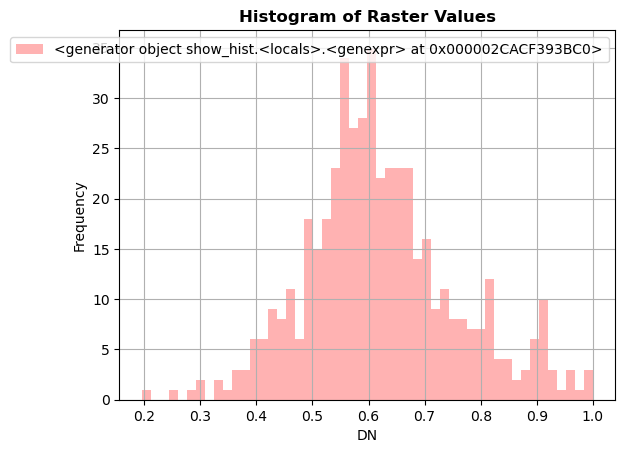

In [3]:
# histogram of index raster values
with rasterio.open(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_clipped.tif") as src:
    show_hist(
        src,
        bins=50,
        lw=0.0,
        stacked=False,
        alpha=0.3,
        histtype='stepfilled',
        title="Histogram of Raster Values"
    )

    plt.show()

### Run weighted zonal statistics - get average score for each neighborhood

In [4]:
# open raster to get its CRS
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_clipped_99.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["mean"], nodata=-99)
stats_mean_values = [f['mean'] for f in stats]

Tenderloin, Chinatown, Financial District, Hayes Valley and Japantown neighborhoods have the highest walkability score.

In [5]:
# add the mean values back into the neighborhood layer
sf_neigh_proj['walkability_mean'] = stats_mean_values
sf_neigh_proj.sort_values(by='walkability_mean', ascending=False).head(5)

,OBJECTID,_id,_version,_created_at,_updated_at,nhood,Shape_Length,Shape_Area,geometry,walkability_mean
25,26,row-jxcs-an7i_724q,rv-j6pa_bxbz-msfa,1697567410955,1697567410955,Tenderloin,0.044985,0.000104,"POLYGON ((-212770.535 -24086.221, -212728.694 ...",0.961169
36,37,row-5kf9.snaa_pnx5,rv-yvgz.8ps5.smzy,1697567410955,1697567410955,Chinatown,0.039727,0.000060,"POLYGON ((-211569.65 -21639.078, -211607.641 -...",0.934115
34,35,row-tdnj~pbrc.4bb2,rv-6uu7_dsyy~hhiw,1697567410955,1697567410955,Financial District/South Beach,0.165459,0.000298,"MULTIPOLYGON (((-209967.035 -23321.133, -20996...",0.881029
29,30,row-6kd7-8adw.cmzq,rv-a7hz_6jp5-nzeh,1697567410955,1697567410955,Hayes Valley,0.058910,0.000130,"POLYGON ((-212918.381 -24224.897, -212908.765 ...",0.877006
27,28,row-sntv.z24m.53dk,rv-kiy7~uhkb.rnuz,1697567410955,1697567410955,Japantown,0.040716,0.000032,"POLYGON ((-213227.247 -22956.182, -213239.834 ...",0.864856


Presidio, Twin Peaks, McLaren Park, Lincoln Park and Seacliff have the lowest walkability scores.

In [6]:
sf_neigh_proj.sort_values(by='walkability_mean', ascending=True).head(5)

,OBJECTID,_id,_version,_created_at,_updated_at,nhood,Shape_Length,Shape_Area,geometry,walkability_mean
6,7,row-xwbi~n5jd~kmsn,rv-qi4f.j6c7-yy4q,1697567410955,1697567410955,Presidio,0.123031,0.000626,"POLYGON ((-215226.394 -20507.624, -215227.266 ...",0.427543
3,4,row-cyst-jf3k~s9cp,rv-emkr.suep.757p,1697567410955,1697567410955,Twin Peaks,0.070638,0.000175,"POLYGON ((-215267.204 -26104.751, -215273.914 ...",0.446673
26,27,row-av6q~vdh9-ma7w,rv-qj3s~442r-ptkm,1697567410955,1697567410955,McLaren Park,0.071590,0.000163,"POLYGON ((-211829.297 -30344.535, -211856.41 -...",0.491619
17,18,row-g7nc-873j~xvgq,rv-sxiz_myqa-yym4,1697567410955,1697567410955,Lincoln Park,0.054499,0.000105,"POLYGON ((-219227.901 -22532.795, -219231.232 ...",0.496325
18,19,row-8suc_2ki4.fznr,rv-f4f4.w2qi~dbsj,1697567410955,1697567410955,Seacliff,0.054192,0.000056,"POLYGON ((-217412.467 -22636.895, -217423.12 -...",0.518729


In [7]:
# average walkability score is 0.66, which is above average SF is generally a very walkable city
sf_neigh_proj['walkability_mean'].mean()

0.663315881872623

### Visualize walkability index

- Folium color guide: https://python-visualization.github.io/folium/latest/advanced_guide/colormaps.html
- Plotting rasters with folium: https://python-visualization.github.io/folium/latest/user_guide/raster_layers/image_overlay.html

In [8]:
map_osm = folium.Map(location=[37.784279, -122.407234], zoom_start=11, tiles="cartodb positron")

folium.Choropleth(
    geo_data=sf_neigh_proj,
    data=sf_neigh_proj, # mean has already been joined into neighborhoods, no need for spatial join
    columns=["nhood", "walkability_mean"],
    key_on="feature.properties.nhood",
    legend_name="Walkability Score (0 to 1)",
    fill_color="GnBu",
    fill_opacity=0.8,
    line_opacity=0.3
).add_to(map_osm)

# show score whenever neighborhood polygon is hovered over
folium.GeoJson(
    sf_neigh_proj,
    style_function=lambda feature: {
        "color": "black",
        "weight": 0.3,
        "fillOpacity":0,
    },
    tooltip=folium.GeoJsonTooltip(fields=['nhood', 'walkability_mean'], aliases=['Neighborhood', 'Score'])
).add_to(map_osm)

In [9]:
# highest walkability score neighborhoods are in the NE
# map_osm.save(r'C:\Users\Yulia\Documents\professional_development\sf_walkability\sf_walkability_choropleth.html')
map_osm

### Plotting raster maps

In [110]:
# open raster to get its CRS
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_clipped.tif"
output_png_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\normalized\final_walkability_index_colored.png"

with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    data=src.read(1)
    

bounds = [[37.70, -122.53], [37.82, -122.35]] 

# define colormap (same as the one used for png raster)
colormap = cm.LinearColormap(
    colors=['#440154', '#3B528B', '#21918C', '#5EC962', '#FDE725'], # viridis color ramp colors
    vmin=np.nanmin(data),
    vmax=np.nanmax(data),
    caption='Walkability Index'
)


# create basemap
m = folium.Map(
    location=[37.78, -122.41],
    zoom_start=12,
    tiles=None  # start blank
)

# add ImageOverlay
folium.raster_layers.ImageOverlay(
    name='Walkability Index',
    image=output_png_path,
    bounds=bounds,
    opacity=0.8,
    interactive=True,
    cross_origin=False,
    zindex=1
).add_to(m)

# add legend
colormap.add_to(m)

folium.GeoJson(
    sf_neigh_proj,
    name = 'Neighborhoods',
    style_function=lambda feature: {
        "color": "black",
        "weight": 1.3,
        "fillOpacity":0,
    },
    tooltip=folium.GeoJsonTooltip(fields=['nhood'], aliases=['Neighborhood'])
).add_to(m)


folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Terrain_Base/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri &mdash; Source: Esri, USGS, NOAA',
    name='ESRI Terrain',
    overlay=False,
    control=True
).add_to(m)

# add layer control
folium.LayerControl().add_to(m)

# highest walkability score neighborhoods are in the NE
# m.save(r'C:\Users\Yulia\Documents\professional_development\sf_walkability\sf_walkability_raster.html')

m

In [109]:
# open raster to get its CRS
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index\normalized\final_walkability_index_clipped.tif"
output_png_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\normalized\final_walkability_index_colored.png"

with rasterio.open(raster_path) as src:
    raster_crs = src.crs
    data=src.read(1)
    

bounds = [[37.70, -122.53], [37.82, -122.35]] 

# define colormap (same as the one used for png raster)
colormap = cm.LinearColormap(
    colors=['#440154', '#3B528B', '#21918C', '#5EC962', '#FDE725'], # viridis color ramp colors
    vmin=np.nanmin(data),
    vmax=np.nanmax(data),
    caption='Walkability Index'
)


# create basemap
m = folium.Map(location=[37.78, -122.41], zoom_start=12, tiles='Stamen Terrain',
               attr="<a href=https://endless-sky.github.io/>Endless Sky</a>")

# add ImageOverlay
folium.raster_layers.ImageOverlay(
    name='Walkability Index',
    image=output_png_path,
    bounds=bounds,
    opacity=0.8,
    interactive=True,
    cross_origin=False,
    zindex=1
).add_to(m)

# add legend
colormap.add_to(m)

folium.GeoJson(
    sf_neigh_proj,
    name = 'Neighborhoods',
    style_function=lambda feature: {
        "color": "black",
        "weight": 1.3,
        "fillOpacity":0,
    },
    tooltip=folium.GeoJsonTooltip(fields=['nhood'], aliases=['Neighborhood'])
).add_to(m)

# add layer control
folium.LayerControl().add_to(m)

# highest walkability score neighborhoods are in the NE
# m.save(r'C:\Users\Yulia\Documents\professional_development\sf_walkability\sf_walkability_raster.html')

m

### Data Overview: General Statistics

In [119]:
# Load input rasters
inputs_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\index"
raster_files = glob(os.path.join(inputs_path, 'input_*.tif'))

raster_data = {}

for f in raster_files:
    with rasterio.open(f) as src:
        data = src.read(1).astype('float64')
        mask = (data != src.nodata) & (data != -9999)
        raster_data[os.path.basename(f)] = np.where(mask, data, np.nan)

index_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\normalized\final_walkability_index.tif"

with rasterio.open(index_path) as src2:
    data2 = src2.read(1).astype('float64')    
    mask2 = (data2 != src2.nodata) & (data2 != -9999)
    raster_data["walkability_index"] = np.where(mask2, data2, np.nan)

df = pd.DataFrame({name: data.flatten() for name, data in raster_data.items()})

# drop rows with any NAs
df_subset = df.dropna()

# calculate correlation
corr_matrix = df.corr()
print(corr_matrix['input_intersection_density.tif'].sort_values(ascending=False))

input_intersection_density.tif    1.000000
walkability_index                 0.676935
input_amenity_count.tif           0.629701
input_lu_entropy.tif              0.587835
input_tree_count.tif              0.546453
input_worldpop.tif                0.350930
input_avg_slope.tif               0.193459
input_dist_to_muni.tif            0.035544
input_avg_walk_dist.tif          -0.059479
Name: input_intersection_density.tif, dtype: float64


In [117]:
intersect_col

'input_intersection_density.tif'

In [112]:
print(corr_matrix["walkability_index"].sort_values(ascending=False))

walkability_index                 1.000000
input_worldpop.tif                0.705075
input_amenity_count.tif           0.680514
input_intersection_density.tif    0.676935
input_tree_count.tif              0.628159
input_lu_entropy.tif              0.467536
input_avg_slope.tif              -0.190681
input_dist_to_muni.tif           -0.497502
input_avg_walk_dist.tif          -0.520046
Name: walkability_index, dtype: float64


<div class="alert alert-block alert-info">
<b>Finding:</b> At the grid level, the highest predictors of walkability are population, amenity count and intersection density. Average street slope has a low correlation with the index, likely because of the relatively low variation of slope values.
</div>

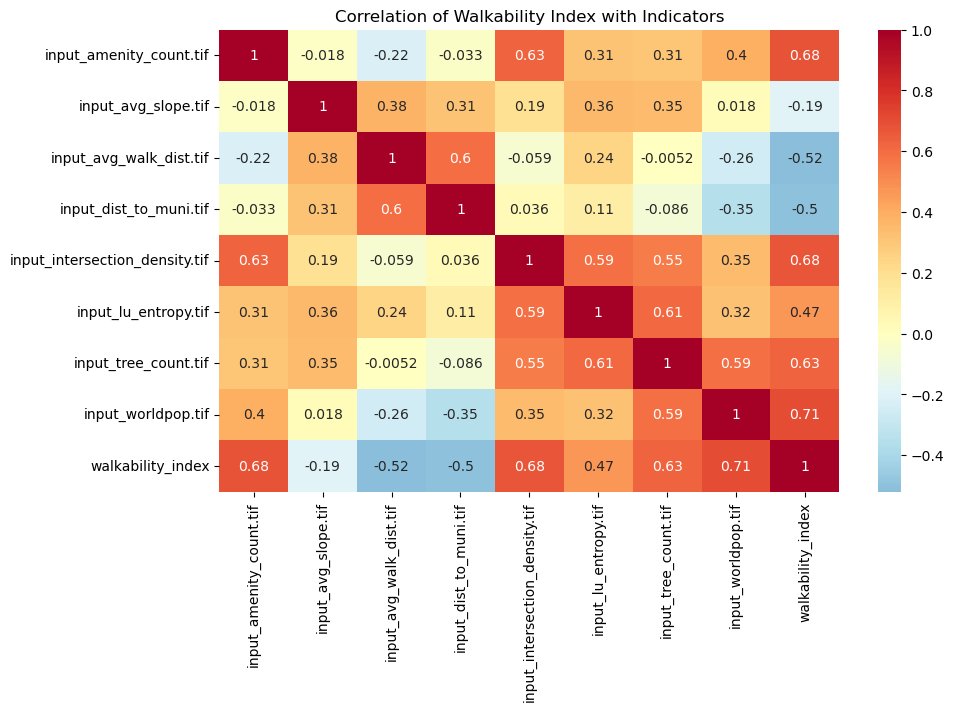

In [113]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,               # or corr_with_index.to_frame() if only one column
    annot=True,                # show correlation values
    cmap='RdYlBu_r',           # diverging color palette (red=low, blue=high)
    center=0
)
plt.title("Correlation of Walkability Index with Indicators")
plt.show()

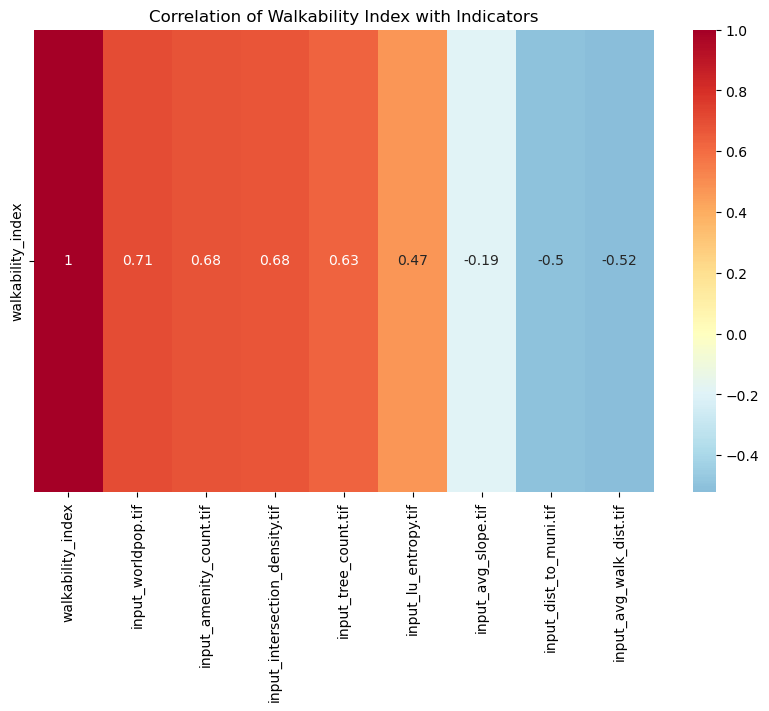

In [114]:
corr_with_index = corr_matrix['walkability_index'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_with_index.to_frame().T,               
    annot=True,                
    cmap='RdYlBu_r',           
    center=0
)
plt.title("Correlation of Walkability Index with Indicators")
plt.show()

### Top 10 vs Bottom 10 Neighborhoods: Characteristics

#### 1. Characteristic: Total Population per Neighborhood

In [11]:
# open raster to get its CRS
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_worldpop.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# # reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["sum"], nodata=-9999)
stats_values_wp = [f['sum'] for f in stats]

#### 2. Characteristic: Total Number of Amenities per Neighborhood

In [12]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_amenity_count.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["sum"], nodata=np.nan)
stats_values_amenity_count = [f['sum'] for f in stats]

#### 3. Characteristic: Sum Tree Count per Neighborhood 

In [13]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_tree_count.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["sum"], nodata=np.nan)
stats_values_trees = [f['sum'] for f in stats]

#### 4. Characteristic: Avg Slope

In [14]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_avg_slope.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["mean"], nodata=np.nan)
stats_values_slope = [f['mean'] for f in stats]

#### 5. Characteristic: Avg Walking Distance to Amenities

In [15]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_avg_walk_dist.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["mean"], nodata=np.nan)
stats_values_dist_amenity = [f['mean'] for f in stats]

#### 6. Characteristic: Avg Distance to Public Transit

In [16]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_dist_to_muni.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["mean"], nodata=np.nan)
stats_values_dist_muni = [f['mean'] for f in stats]

#### 7. Characteristic: Intersection Density

In [17]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_intersection_density.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["sum"], nodata=np.nan)
stats_values_intersect_density = [f['sum'] for f in stats]

#### 8. Characteristic: Avg Entropy

In [18]:
raster_path = r"C:\Users\Yulia\Documents\professional_development\sf_walkability\Index\input_lu_entropy.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

# reproject 
# sf_neigh_proj = sf_neigh.to_crs(raster_crs)

stats = zonal_stats(sf_neigh_proj, raster_path, stats=["mean"], nodata=np.nan)
stats_values_avg_entropy = [f['mean'] for f in stats]

#### Combine stats into one table

In [19]:
sf_neigh_proj['wp'] = stats_values_wp
sf_neigh_proj['amenity_count'] = stats_values_amenity_count
sf_neigh_proj['trees'] = stats_values_trees
sf_neigh_proj['slope'] = stats_values_slope
sf_neigh_proj['dist_amenity'] = stats_values_dist_amenity
sf_neigh_proj['dist_transit'] = stats_values_dist_muni
sf_neigh_proj['intersect_density'] = stats_values_intersect_density
sf_neigh_proj['entropy'] = stats_values_avg_entropy
sf_neigh_proj.head(5)

,OBJECTID,_id,_version,_created_at,_updated_at,nhood,Shape_Length,Shape_Area,geometry,walkability_mean,wp,amenity_count,trees,slope,dist_amenity,dist_transit,intersect_density,entropy
0,1,row-kat6_uieb_3jtd,rv-dbu2~hpud.6yya,1697567410955,1697567410955,Western Addition,0.068756,0.000155,"POLYGON ((-212941.285 -22937.693, -212936.639 ...",0.809758,581.672913,218.0,4752.0,0.027331,62.953711,148.474780,699.0,0.710611
1,2,row-z3d4_b3is_mfk7,rv-zi62-zgjg-kwse,1697567410955,1697567410955,West of Twin Peaks,0.148762,0.000810,"POLYGON ((-216522.611 -26694.102, -216554.451 ...",0.596170,1069.387451,209.0,14325.0,0.048864,221.387796,163.929098,2866.0,0.651511
2,3,row-xwem-yyxg.b4xp,rv-n2ba~749k.nkaj,1697567410955,1697567410955,Visitacion Valley,0.076977,0.000162,"POLYGON ((-211583.017 -30393.597, -211600.076 ...",0.524651,441.632690,9.0,1183.0,0.043399,419.820475,128.815165,348.0,0.511031
3,4,row-cyst-jf3k~s9cp,rv-emkr.suep.757p,1697567410955,1697567410955,Twin Peaks,0.070638,0.000175,"POLYGON ((-215267.204 -26104.751, -215273.914 ...",0.446673,248.746689,35.0,1158.0,0.079690,315.965018,191.320818,352.0,0.361117
4,5,row-zga5_xbxp_wavz,rv-dhre.4pg3-htj9,1697567410955,1697567410955,South of Market,0.069793,0.000234,"POLYGON ((-211386.739 -23146.622, -211434.309 ...",0.847147,1270.584961,848.0,5690.0,0.011931,33.372955,100.362573,1538.0,0.676027


### Data Viz: Grouped Bar Plot, Top 10 vs Bottom 10 Neighborhoods

Comparing metrics for top 10 (in terms of walkability score) and bottom 10 (in terms of walkability score) neighborhoods across different metrics, such as population, tree count and distance to public transit. Is there a noticeable difference between these neighborhoods?

In [20]:
top_10 = sf_neigh_proj.copy()
top_10 = top_10.sort_values(by='walkability_mean', ascending=False).head(10)
top_10 = top_10[['walkability_mean', 'wp', 'amenity_count', 'trees', 'slope',
                 'dist_amenity', 'dist_transit', 'intersect_density', 'entropy']]
top_10 = top_10.mean().to_frame('value').reset_index().rename(columns={'index':'indicator'})
top_10['group'] = 'Top 10'

In [21]:
bottom_10 = sf_neigh_proj.copy()
bottom_10 = bottom_10.sort_values(by='walkability_mean', ascending=True).head(10)
bottom_10 = bottom_10[['walkability_mean', 'wp', 'amenity_count', 'trees', 'slope',
                 'dist_amenity', 'dist_transit', 'intersect_density', 'entropy']]
bottom_10 = bottom_10.mean().to_frame('value').reset_index().rename(columns={'index':'indicator'})
bottom_10['group'] = 'Bottom 10'

In [22]:
top_bottom_merged = pd.concat([top_10, bottom_10])
top_bottom_merged

,indicator,value,group
0,walkability_mean,0.858686,Top 10
1,wp,760.057938,Top 10
2,amenity_count,561.900000,Top 10
3,trees,4715.100000,Top 10
4,slope,0.031032,Top 10
5,dist_amenity,43.583268,Top 10
6,dist_transit,103.467749,Top 10
7,intersect_density,989.200000,Top 10
8,entropy,0.708561,Top 10
0,walkability_mean,0.511233,Bottom 10


In [23]:
top_bottom_merged['indicator'] = top_bottom_merged['indicator'].replace({'walkability_mean':'Walkability Mean',
                                                                      'wp' : 'Population',
                                                                      'amenity_count' : 'Amenity Count',
                                                                      'trees' : 'Tree Count',
                                                                      'slope' : 'Slope',
                                                                      'dist_amenity' : 'Distance to Amenity',
                                                                      'dist_transit' : 'Distance to Public Transit',
                                                                      'intersect_density' : 'Intersection Density',
                                                                      'entropy' : 'Land Use Entropy Score'
                                                                      })

top_bottom_merged

,indicator,value,group
0,Walkability Mean,0.858686,Top 10
1,Population,760.057938,Top 10
2,Amenity Count,561.900000,Top 10
3,Tree Count,4715.100000,Top 10
4,Slope,0.031032,Top 10
5,Distance to Amenity,43.583268,Top 10
6,Distance to Public Transit,103.467749,Top 10
7,Intersection Density,989.200000,Top 10
8,Land Use Entropy Score,0.708561,Top 10
0,Walkability Mean,0.511233,Bottom 10


#### Data Viz #1: Grouped Bar Plot, Population, Amenity Count, Tree Count

In [24]:
data1 = top_bottom_merged[top_bottom_merged['indicator'].isin(['Population', 'Amenity Count', 'Tree Count'])]
data1

,indicator,value,group
1,Population,760.057938,Top 10
2,Amenity Count,561.900000,Top 10
3,Tree Count,4715.100000,Top 10
1,Population,433.529713,Bottom 10
2,Amenity Count,93.400000,Bottom 10
3,Tree Count,2935.100000,Bottom 10


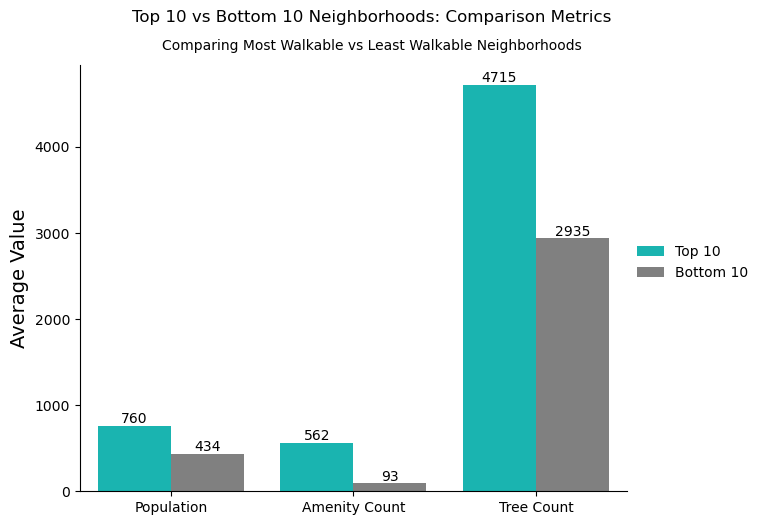

In [25]:
g1 = sns.catplot(
    data=data1, kind="bar",
    x="indicator", y="value", hue='group',
    height=5, aspect=1.3, palette = ['#00cec8', '#808080'])

g1 = g1.set_axis_labels('', 'Average Value')
g1._legend.set_title('')
# g1.tight_layout()
g1.fig.suptitle("Top 10 vs Bottom 10 Neighborhoods: Comparison Metrics", y=1.08)
g1 = g1.set_ylabels(fontsize=14)

g1.fig.text(x=0.5, y=1, s="Comparing Most Walkable vs Least Walkable Neighborhoods", ha='center', fontsize=10)


for ax in g1.axes.flat:
    for p in ax.patches:
        # get the height of the bar (or width for horizontal bars)
        height = p.get_height()
        # add the annotation
        ax.annotate(str(round(height)),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 5),  # Offset text slightly above the bar
                    textcoords='offset points')
        
        
# g1.savefig(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data_viz\bargraph1.png", dpi=300)

g1

#### Data Viz #2: Grouped Bar Plot, Distance to amenities and public transit, intersection density

In [27]:
data2 = top_bottom_merged[top_bottom_merged['indicator'].isin(['Distance to Amenity', 'Distance to Public Transit', 'Intersection Density'])]
data2

,indicator,value,group
5,Distance to Amenity,43.583268,Top 10
6,Distance to Public Transit,103.467749,Top 10
7,Intersection Density,989.200000,Top 10
5,Distance to Amenity,232.833076,Bottom 10
6,Distance to Public Transit,244.436136,Bottom 10
7,Intersection Density,722.000000,Bottom 10


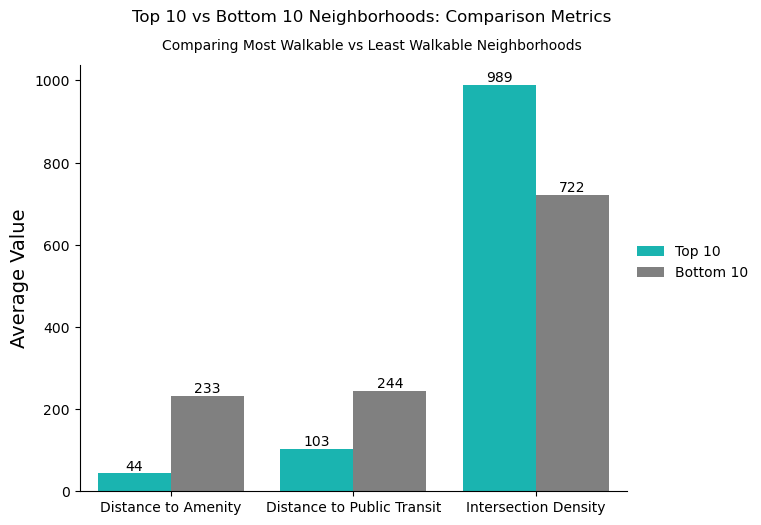

In [28]:
g2 = sns.catplot(
    data=data2, kind="bar",
    x="indicator", y="value", hue='group',
    height=5, aspect=1.3, palette = ['#00cec8', '#808080'])

g2 = g2.set_axis_labels('', 'Average Value')
g2._legend.set_title('')
# g1.tight_layout()
g2.fig.suptitle("Top 10 vs Bottom 10 Neighborhoods: Comparison Metrics", y=1.08)
g2 = g2.set_ylabels(fontsize=14)

g2.fig.text(x=0.5, y=1, s="Comparing Most Walkable vs Least Walkable Neighborhoods", ha='center', fontsize=10)


for ax in g2.axes.flat:
    for p in ax.patches:
        # get the height of the bar (or width for horizontal bars)
        height = p.get_height()
        # add the annotation
        ax.annotate(str(round(height)),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 5),  # Offset text slightly above the bar
                    textcoords='offset points')
        
        
# g1.savefig(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data_viz\bargraph1.png", dpi=300)

g2

#### Data Viz #3: Relationship Between Walkability and Population

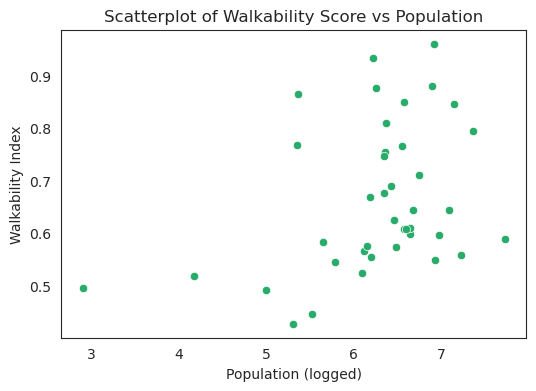

In [57]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(6,4))
    s1 = sns.scatterplot(data=sf_neigh_proj, x=np.log1p(sf_neigh_proj["wp"]),
                         y="walkability_mean", color=["#29ab6a"], ax=ax)
    ax.set_title("Scatterplot of Walkability Score vs Population")
    ax.set_xlabel("Population (logged)")
    ax.set_ylabel("Walkability Index")
#     plt.savefig(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data_viz\scatterplot2.png", dpi=300)
    s1

#### Data Viz #4: Relationship Between Walkability and Land Use Entropy

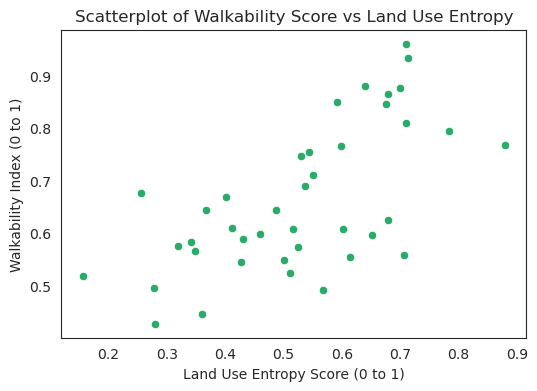

In [55]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(6,4))
    s2 = sns.scatterplot(data=sf_neigh_proj, x="entropy",
                         y="walkability_mean", color=["#29ab6a"], ax=ax)
    ax.set_title("Scatterplot of Walkability Score vs Land Use Entropy")
    ax.set_xlabel("Land Use Entropy Score (0 to 1)")
    ax.set_ylabel("Walkability Index (0 to 1)")
#     plt.savefig(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data_viz\scatterplot2.png", dpi=300)
    s2

#### Data Viz #5: Relationship Between Walkability and Distance to Public Transit

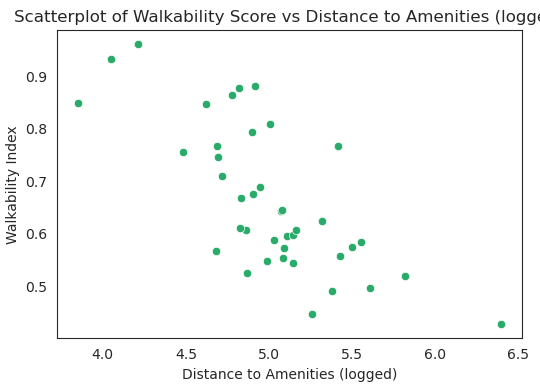

In [59]:
with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(6,4))
    s3 = sns.scatterplot(data=sf_neigh_proj, x=np.log1p(sf_neigh_proj["dist_transit"]),
                         y="walkability_mean", color=["#29ab6a"], ax=ax)
    ax.set_title("Scatterplot of Walkability Score vs Distance to Amenities (logged)")
    ax.set_xlabel("Distance to Amenities (logged)")
    ax.set_ylabel("Walkability Index")
    plt.savefig(r"C:\Users\Yulia\Documents\professional_development\sf_walkability\data_viz\scatterplot3.png", dpi=300)
    s3